# Machine Learning CA1 – Student Outcome Classification

---

| | |
|---|---|
| **Programme** | BSc (Hons) in Computing – Artificial Intelligence |
| **Module** | Machine Learning for AI |
| **Lecturer** | David McQuaid |
| **Assignment** | ML_CA1_V7 |
| **Submission Deadline** | 19/04/2026 at 11:59 pm |

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis)
3. [Data Preparation](#3-data-preparation)
4. [Classification Algorithms](#4-classification-algorithms)
5. [Final Classification and Accuracy Analysis](#5-final-classification)
6. [Conclusions](#6-conclusions)
7. [References](#7-references)


---
## 1. Introduction

This notebook covers the full ML pipeline for the CCT College Dublin Machine Learning CA1 assignment. The dataset (`student_dataV3.csv`) has demographic, socio-economic, and academic data for students at a Portuguese higher education institution. The goal is to classify each student as **Dropout**, **Enrolled**, or **Graduate** by the end of their normal course duration.

The work is split into four main parts:

- **Section 2** — EDA: getting to know the data, spotting distributions, relationships, and any quality issues (spoiler: there are a few).
- **Section 3** — Data Preparation: cleaning up the mess found in EDA and getting everything ready for modelling.
- **Section 4** — Classification Algorithms: building and tuning at least two classifiers, comparing results.
- **Section 5** — Final Classification: running the best model on the test set and analysing how well it generalises.

The dataset was originally published by Realinho et al. (2022) and has been widely used in educational data mining research.


---
## 2. Exploratory Data Analysis

### 2.1 Loading Libraries and the Dataset

Before doing anything else, let's load the data and take a look at what we're working with. We'll load it raw — no preprocessing yet — so we can see any data quality issues as they actually are.


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Load raw data (keep as-is to expose dirty values)
df_raw = pd.read_csv('student_dataV3.csv')

# Normalise Target column: fix case/abbreviation inconsistencies
target_map = {
    'Grad': 'Graduate', 'graduate': 'Graduate',
    'Drop': 'Dropout',  'dropout': 'Dropout',
    'enrolled': 'Enrolled'
}
df_raw['Target'] = df_raw['Target'].replace(target_map)

print(f"Dataset shape: {df_raw.shape}")
print(f"Target classes after normalisation: {sorted(df_raw['Target'].unique())}")
df_raw.head()


Dataset shape: (4424, 37)
Target classes after normalisation: ['Dropout', 'Enrolled', 'Graduate']


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 2.2 Dataset Overview and Data Types


In [4]:
print("=== Data Types ===")
print(df_raw.dtypes)


=== Data Types ===
Marital status                                     object
Application mode                                    int64
Application order                                   int64
Course                                            float64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                            float64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                          object
Educational special needs                           int64
Debtor                                            float64
Tuition fees up to date                            ob

### 2.3 Dirty Data and Missing Value Detection

One of the first things worth checking is whether the data is actually clean. In this case, it's not — and the issues aren't all in the standard `NaN` format either.


In [5]:
# Identify all non-numeric values in columns that should be numeric
dirty_summary = {}
for col in df_raw.columns:
    if col == 'Target':
        continue
    series = df_raw[col]
    non_num_mask = pd.to_numeric(series, errors='coerce').isna()
    non_num_vals = series[non_num_mask]
    if len(non_num_vals) > 0:
        dirty_summary[col] = {
            'Count': len(non_num_vals),
            'Values Found': str(non_num_vals.unique().tolist())
        }

dirty_df = pd.DataFrame(dirty_summary).T
print(f"Columns with dirty/missing values: {len(dirty_df)}")
print()
print(dirty_df.to_string())


Columns with dirty/missing values: 13

                                    Count Values Found
Marital status                          1        ['?']
Course                                  1        [nan]
Father's qualification                  1        [nan]
Admission grade                         1        [nan]
Displaced                               1        ['?']
Debtor                                  1        [nan]
Tuition fees up to date                 2   [nan, '?']
Age at enrollment                       1  ['UnKnown']
International                           1        [nan]
Curricular units 1st sem (credited)     1       ['Na']
Curricular units 1st sem (grade)        1        [nan]
Curricular units 2nd sem (enrolled)     1        [nan]
Curricular units 2nd sem (grade)        1        [nan]


**EDA Finding 2.3 — Dirty Data:** The dataset has some data quality issues that aren't immediately obvious from the column types:

- **`'?'`** shows up in `Marital status`, `Displaced`, and `Tuition fees up to date` — probably representing unknown or refused answers.
- **`'UnKnown'`** appears in `Age at enrollment` — someone clearly wasn't consistent with their naming.
- **`'Na'`** in `Curricular units 1st sem (credited)` — a string version of a missing value.
- **Standard `NaN`** values are scattered across several other columns.
- **Target column inconsistencies**: The `Target` column also has variant spellings like `'Grad'`, `'graduate'`, `'Drop'`, and `'dropout'` — these all need to be normalised to the canonical values before any analysis.

These dirty values cause pandas to read entire columns as strings, which breaks any numerical analysis. This is exactly the kind of thing we need to fix in the data preparation phase.


### 2.4 Target Variable Distribution

Before building any model, it's worth checking how balanced the target classes are. Imbalanced classes can lead to models that just predict the majority class and still look decent on paper.


          Count  Percentage (%)
Target                         
Graduate   2209           49.93
Dropout    1421           32.12
Enrolled    794           17.95


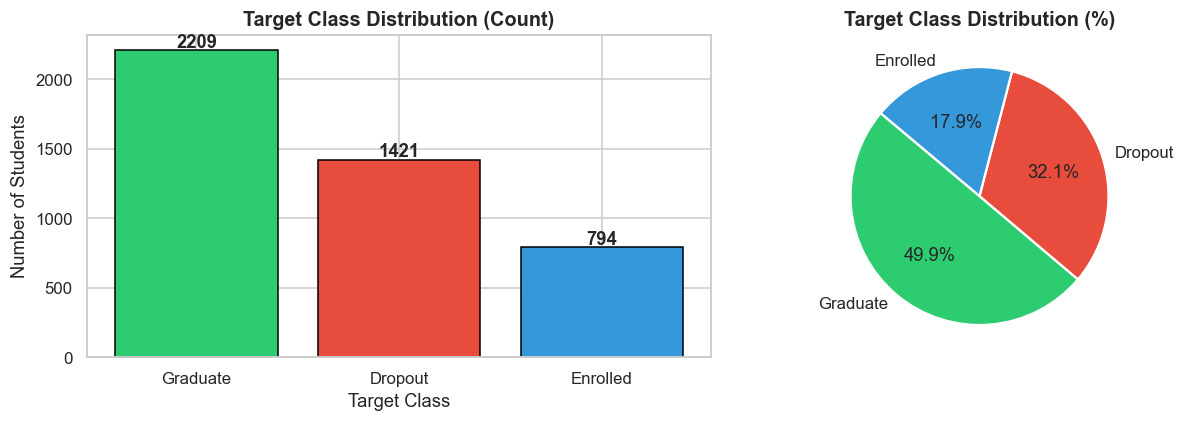

Figure saved.


In [6]:
target_counts = df_raw['Target'].value_counts()
target_pct = df_raw['Target'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct.round(2)
})
print(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette_target = {'Dropout': '#e74c3c', 'Enrolled': '#3498db', 'Graduate': '#2ecc71'}
colors = [palette_target[k] for k in target_counts.index]

axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_target_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.4:** The dataset is moderately imbalanced — *Graduate* is the majority class (~50%), followed by *Dropout* (~32%), with *Enrolled* being the smallest group (~18%). This matters because a naive classifier could just predict "Graduate" for everyone and still get ~50% accuracy without learning anything useful. We'll use stratified splitting and class-weight balancing to handle this.


### 2.5 Descriptive Statistics

Let's get a quick numerical summary of the continuous features. We'll temporarily coerce everything to numeric to make this work.


In [7]:
# Coerce all feature columns to numeric for descriptive stats
df_num_preview = df_raw.copy()
for col in df_num_preview.columns:
    if col != 'Target':
        df_num_preview[col] = pd.to_numeric(df_num_preview[col], errors='coerce')

df_num_preview.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Marital status,4423.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4423.0,8856.46,2063.76,33.00,9085.00,9238.00,9556.00,9991.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mother's qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Father's qualification,4423.0,22.27,15.34,1.00,3.00,19.00,37.00,44.00


### 2.6 Distribution of Continuous Features

Let's look at the distributions of the key numerical features to spot any skewness, outliers, or unusual patterns.


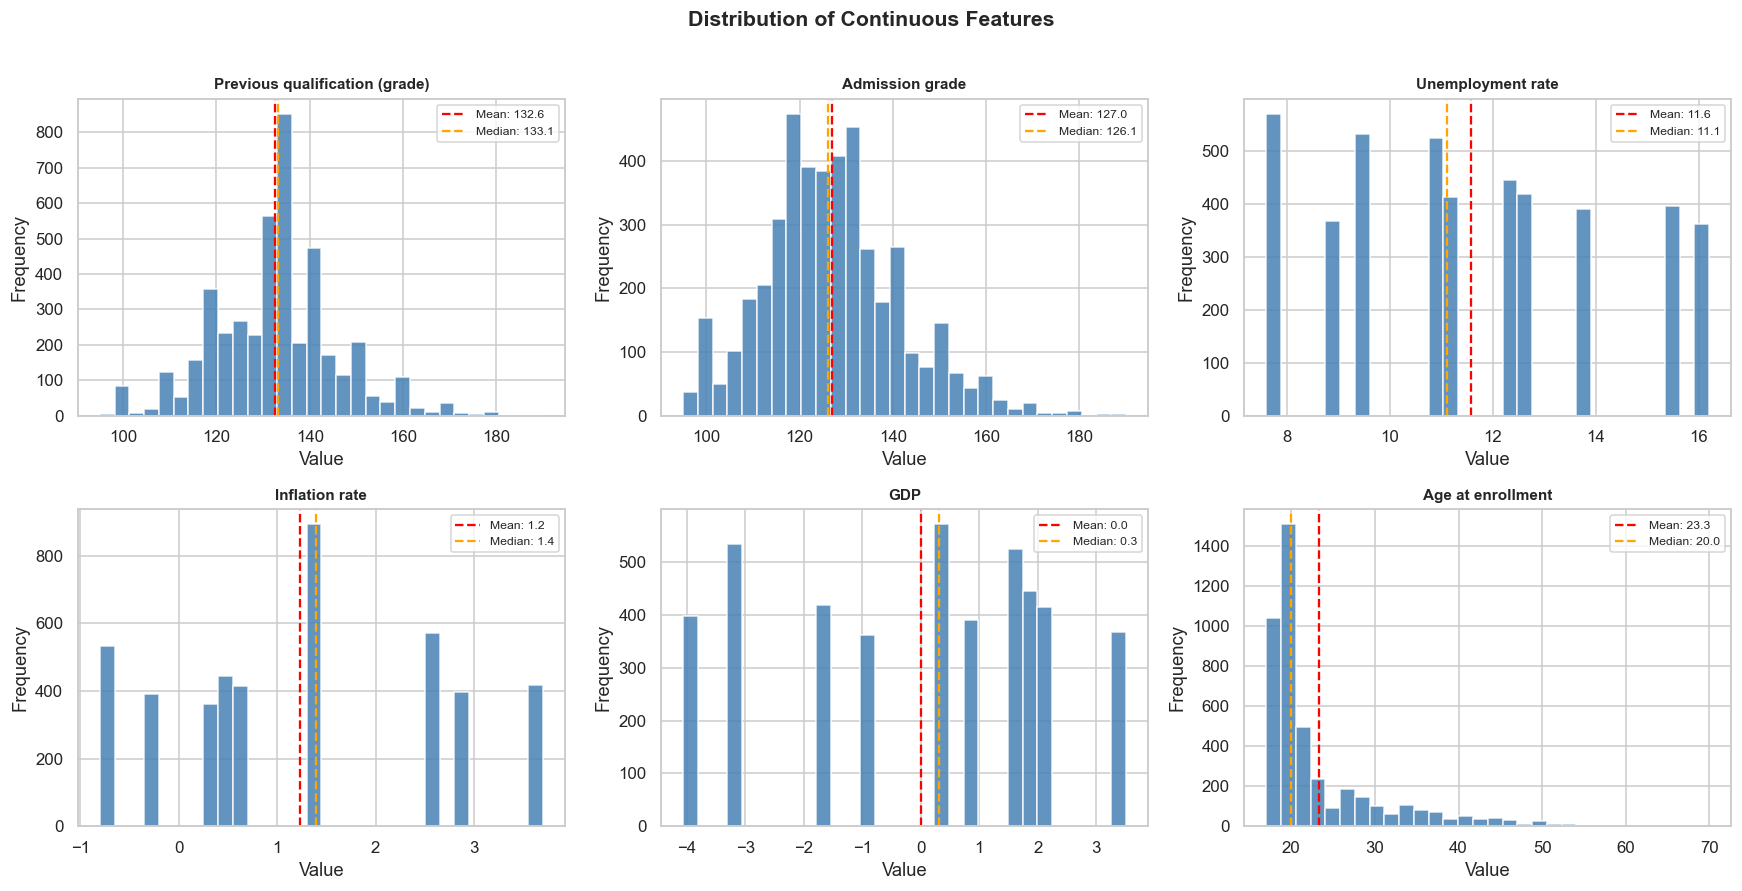

Figure saved.


In [8]:
continuous_cols = ['Previous qualification (grade)', 'Admission grade',
                   'Unemployment rate', 'Inflation rate', 'GDP',
                   'Age at enrollment']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    series = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    axes[i].hist(series, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(series.mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {series.mean():.1f}')
    axes[i].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Median: {series.median():.1f}')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Continuous Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_continuous_distributions.png', bbox_inches='tight')
plt.show()
print("Figure saved.")
